In [1]:
# Comprensión de los datos
import pandas as pd

df = pd.read_csv("../data/dataset_pictogramas.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         195 non-null    int64 
 1   palabra    195 non-null    object
 2   categoria  195 non-null    object
 3   archivo    195 non-null    object
 4   url        195 non-null    object
dtypes: int64(1), object(4)
memory usage: 7.7+ KB


In [2]:
# Eliminar posibles duplicados
df_clean = df.drop_duplicates()
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 193 entries, 0 to 194
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         193 non-null    int64 
 1   palabra    193 non-null    object
 2   categoria  193 non-null    object
 3   archivo    193 non-null    object
 4   url        193 non-null    object
dtypes: int64(1), object(4)
memory usage: 9.0+ KB


In [3]:
# Longitud del dataset
print(f"Longitud del dataset limpio: {len(df_clean)}")

Longitud del dataset limpio: 193


categoria
acciones      30
animales      27
objetos       26
comida        24
numeros       17
lugares       16
emociones     13
colores       12
saludos       10
familia       10
transporte     8
Name: count, dtype: int64


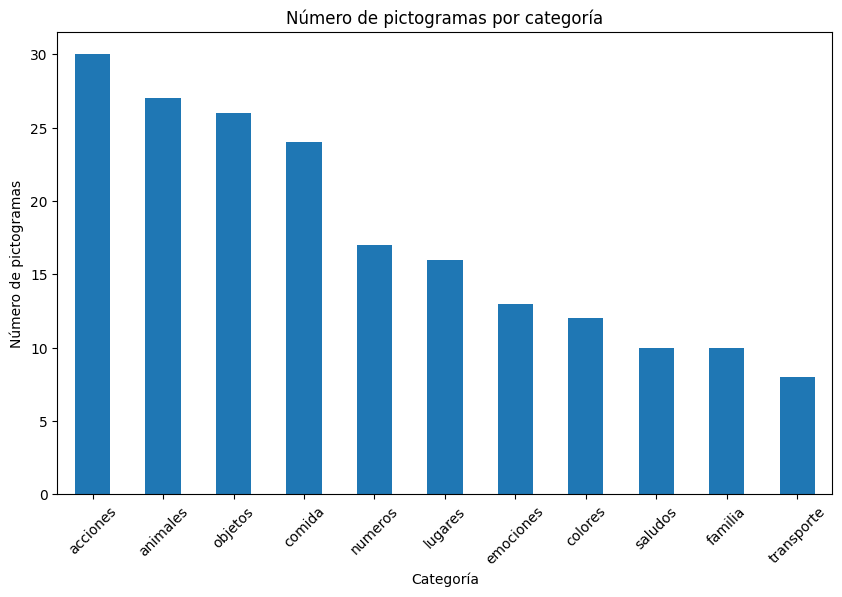

In [4]:
import matplotlib.pyplot as plt
category_counts = df_clean['categoria'].value_counts()
print(category_counts)

# Visualizar la distribución de categorías
plt.figure(figsize=(10, 6))
category_counts.plot(kind='bar')
plt.title('Número de pictogramas por categoría')
plt.xlabel('Categoría')
plt.ylabel('Número de pictogramas')
plt.xticks(rotation=45)
plt.show()

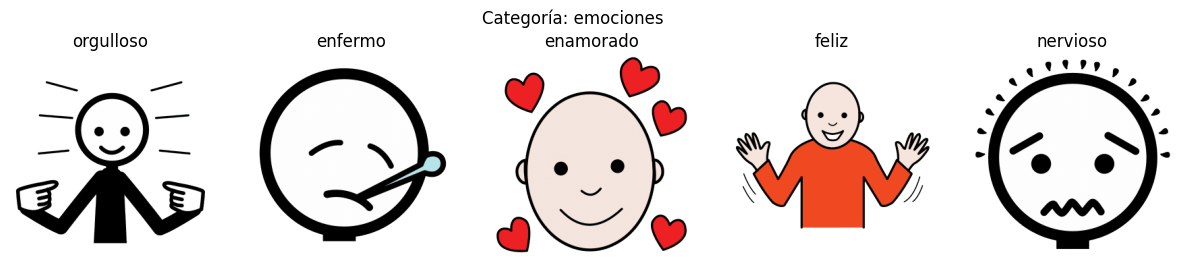

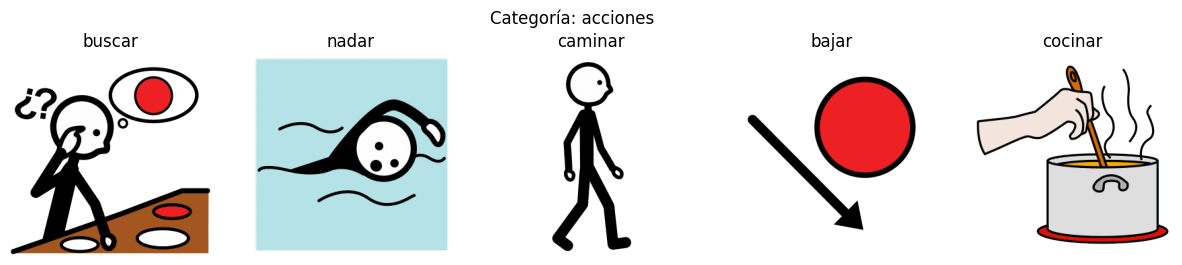

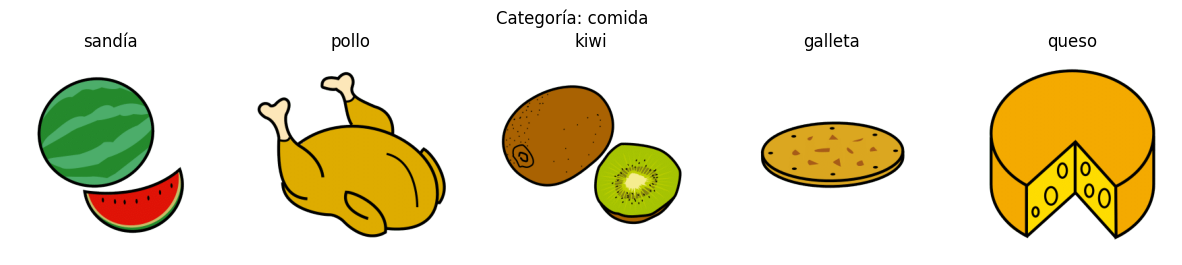

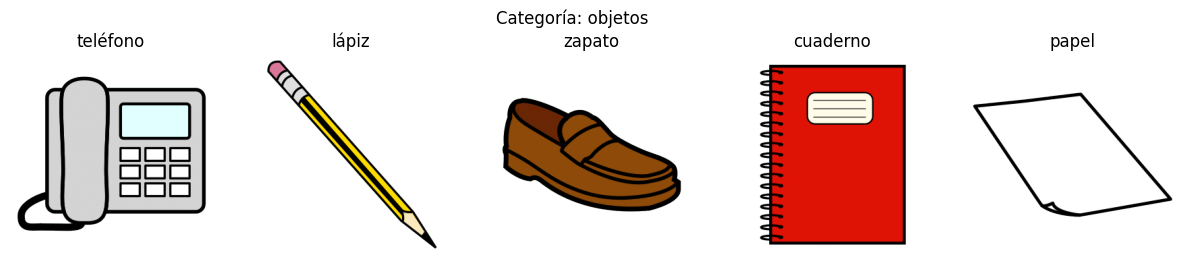

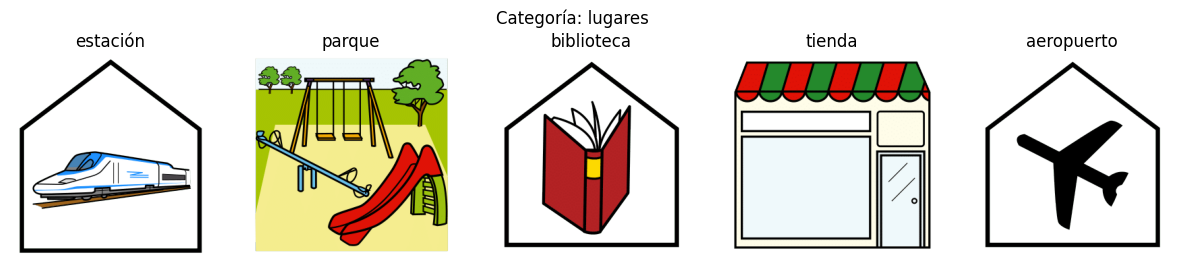

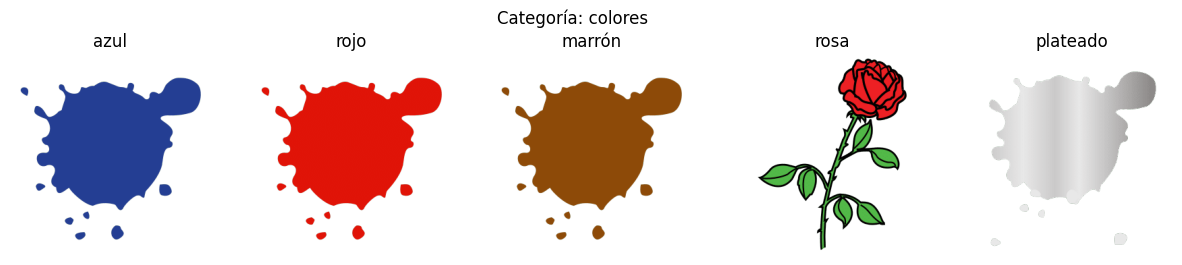

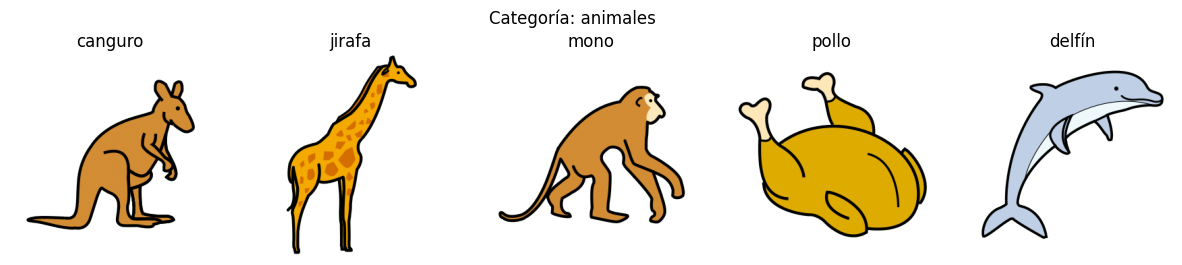

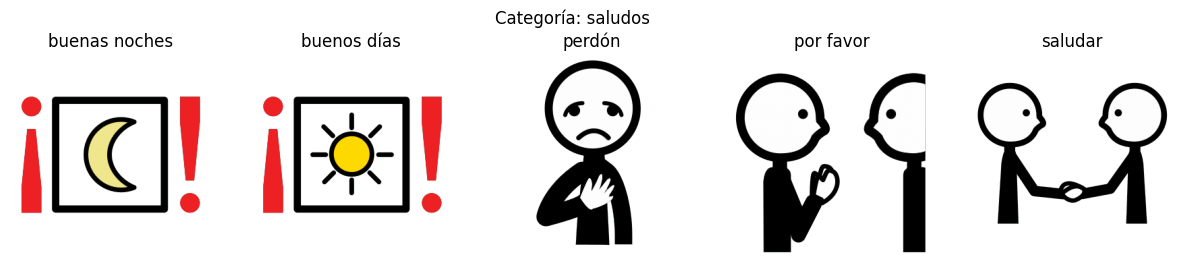

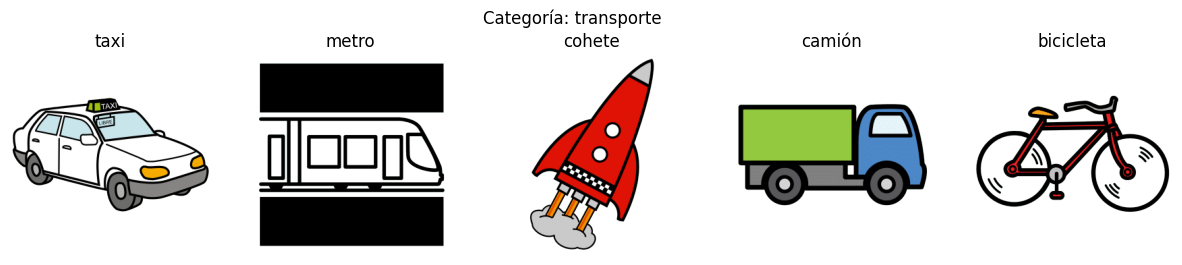

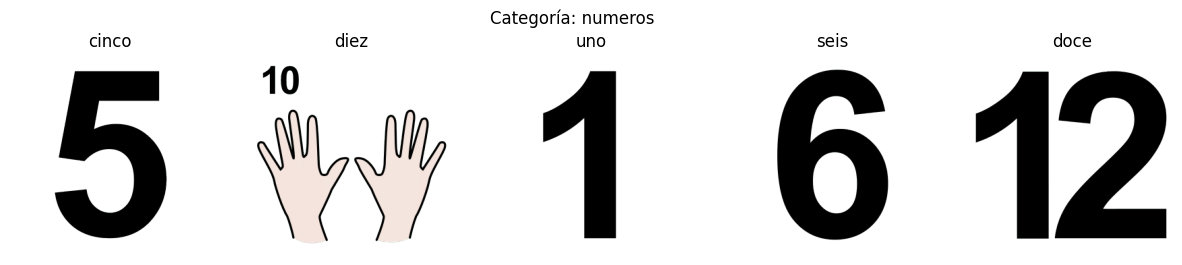

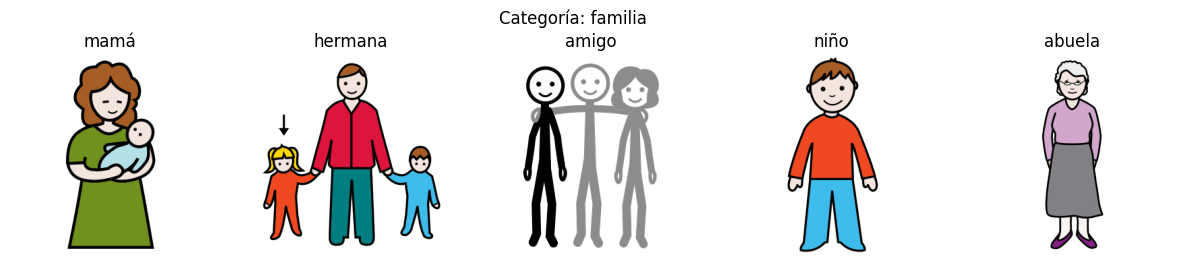

In [5]:
# Visualizar cinco pictogramas de ejemplo por categoría
import random
from PIL import Image
import os
categories = df_clean['categoria'].unique()
for category in categories:
    sample_images = df_clean[df_clean['categoria'] == category].sample(5) # Cinco por categoría
    plt.figure(figsize=(15, 3))
    for i, (_, row) in enumerate(sample_images.iterrows()):
        img_path = os.path.join("../data", row['archivo'])
        img = Image.open(img_path)
        plt.subplot(1, 5, i + 1) # Muestra las imágenes en una fila de cinco columnas
        plt.imshow(img)
        plt.axis('off')
        plt.title(row['palabra']) # Agregamos el título con la palabra   
    plt.suptitle(f'Categoría: {category}')
    plt.show()

In [6]:
pip install wordcloud

Note: you may need to restart the kernel to use updated packages.


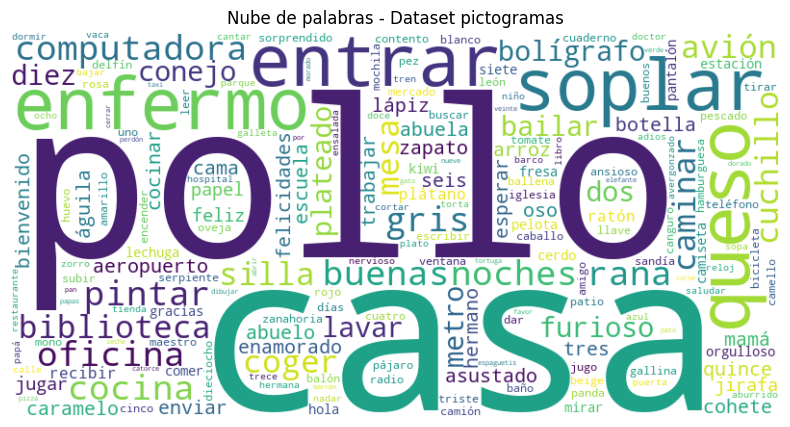

In [7]:
from wordcloud import WordCloud

text = " ".join(df_clean['palabra'])
wc = WordCloud(width=800, height=400, background_color="white").generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Nube de palabras - Dataset pictogramas")
plt.show()

In [9]:
pip install unidecode

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.1.2 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
# NORMALIZACIÓN DE TEXTO
# Convertir todas las palabras a minúsculas
from unidecode import unidecode
df_clean['palabra'] = df_clean['palabra'].str.lower().apply(unidecode) # Quitamos tildes por facilidad

C:\Users\Mauricio\AppData\Local\Temp\ipykernel_2396\3386253248.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['palabra'] = df_clean['palabra'].str.lower().apply(unidecode) # Quitamos tildes por facilidad


In [9]:
picto_dict = dict(zip(df_clean['palabra'], df_clean['archivo']))

In [ ]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(df_clean, test_size=0.3, random_state=42) # 70% para entrenamiento
# 30% restante se divide en 15% validación y 15% test
val, test = train_test_split(test, test_size=0.5, random_state=42)
# Se añade una columna para indicar el split
train['split'] = 'train'
val['split'] = 'val'
test['split'] = 'test'
# Se unen los dataframes en df_final
df_final = pd.concat([train, val, test])
df_final.to_csv("../data/dataset_pictogramas_split.csv", index=False, encoding="utf-8")

In [16]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report

# Dataset palabra → categoría
X = df_clean['palabra']
y = df_clean['categoria'] # A predecir empleando palabras

# Dividir train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
# 70% para entrenamiento, 30% para test
# Vectorización con N-gramas (1-2)
# Vectorización con TF-IDF y n-gramas (1-2)
vectorizer = TfidfVectorizer(ngram_range=(1,2))
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# Modelo Naive Bayes
nb = MultinomialNB() # Entrenamiento del modelo
nb.fit(X_train_vec, y_train)

# Predicciones
y_pred = nb.predict(X_test_vec)

# Reporte de métricas
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

    acciones       0.19      1.00      0.32        11
    animales       0.00      0.00      0.00         9
     colores       0.00      0.00      0.00         2
      comida       0.00      0.00      0.00         5
   emociones       0.00      0.00      0.00         2
     familia       0.00      0.00      0.00         6
     lugares       0.00      0.00      0.00         7
     numeros       0.00      0.00      0.00         2
     objetos       0.00      0.00      0.00         9
     saludos       0.00      0.00      0.00         2
  transporte       0.00      0.00      0.00         3

    accuracy                           0.19        58
   macro avg       0.02      0.09      0.03        58
weighted avg       0.04      0.19      0.06        58



c:\Users\Mauricio\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Mauricio\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Mauricio\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _war

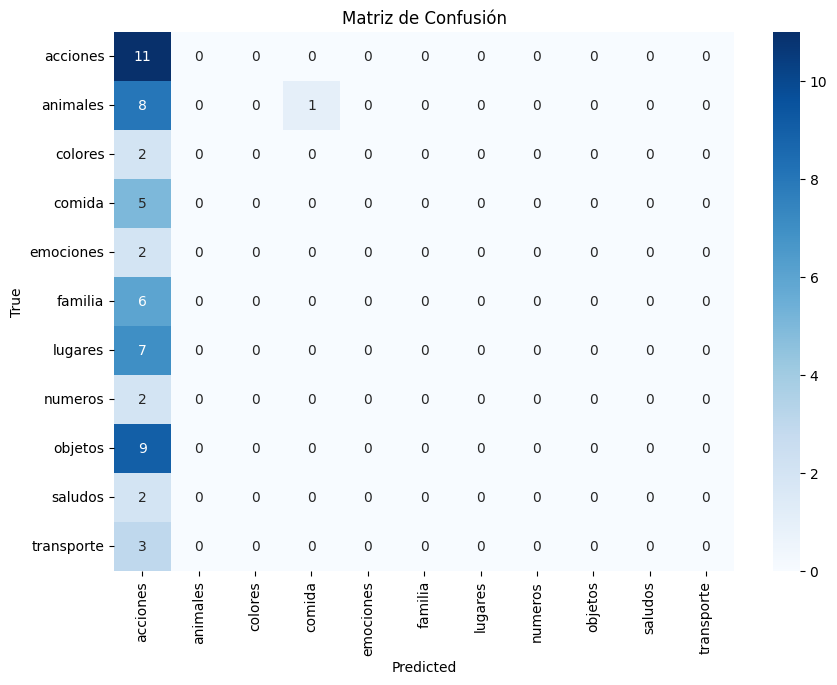

In [18]:
# Agregar matriz de confusión
from sklearn.metrics import confusion_matrix
import seaborn as sns
cm = confusion_matrix(y_test, y_pred, labels=nb.classes_)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=nb.classes_, yticklabels=nb.classes_, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Matriz de Confusión')
plt.show()

In [19]:
# Modelo defectuoso.
# Probraremos suerte con BERT

!pip install transformers
!pip install torch

   ---------------------------------------- 0.0/241.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/241.3 MB ? eta -:--:--
   ---------------------------------------- 0.5/241.3 MB 1.5 MB/s eta 0:02:38
   ---------------------------------------- 0.8/241.3 MB 1.6 MB/s eta 0:02:31
   ---------------------------------------- 1.3/241.3 MB 1.8 MB/s eta 0:02:16
   ---------------------------------------- 1.8/241.3 MB 2.0 MB/s eta 0:02:02
   ---------------------------------------- 2.4/241.3 MB 2.2 MB/s eta 0:01:51
    --------------------------------------- 3.1/241.3 MB 2.4 MB/s eta 0:01:40
    --------------------------------------- 3.9/241.3 MB 2.6 MB/s eta 0:01:32
    --------------------------------------- 4.7/241.3 MB 2.8 MB/s eta 0:01:26
    --------------------------------------- 5.5/241.3 MB 2.9 MB/s eta 0:01:21
   - -------------------------------------- 6.6/241.3 MB 3.0 MB/s eta 0:01:17
   - -------------------------------------- 7.3/241.3 MB 3.2 MB/s eta 0:01:14


In [21]:
from transformers import BertTokenizer, BertModel
import torch
from sklearn.preprocessing import LabelEncoder

In [22]:
texts = df_clean['palabra'].tolist()
labels = df_clean['categoria'].tolist()

# Codificamos las etiquetas como números
le = LabelEncoder()
labels_encoded = le.fit_transform(labels)


In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(texts, labels_encoded, test_size=0.2, random_state=42)


In [24]:
# Tokenizar con BERT
from transformers import BertTokenizer

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

train_encodings = tokenizer(X_train, truncation=True, padding=True)
test_encodings = tokenizer(X_test, truncation=True, padding=True)


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

c:\Users\Mauricio\AppData\Local\Programs\Python\Python312\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Mauricio\.cache\huggingface\hub\models--bert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

In [25]:
class PictogramDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels
    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item
    def __len__(self):
        return len(self.labels)

train_dataset = PictogramDataset(train_encodings, y_train)
test_dataset = PictogramDataset(test_encodings, y_test)


In [26]:
from transformers import BertForSequenceClassification, Trainer, TrainingArguments

model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=len(le.classes_))

training_args = TrainingArguments(
    output_dir='./results',
    evaluation_strategy="epoch",
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=4,
    logging_dir='./logs',
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
)

trainer.train()


Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


TypeError: TrainingArguments.__init__() got an unexpected keyword argument 'evaluation_strategy'

In [ ]:
# RECOMENDACIONES DE COPILOT:
"""🤖 4. Modelo base del chatbot
Ya que el profesor pidió algo simple pero funcional, puedes empezar con:
🔹 Reglas simples
- Si el niño elige “queso”, el chatbot responde: “¿Te gusta el queso?” y muestra otro pictograma de comida.
🔹 Clasificación por categoría
- Usa Naive Bayes para clasificar frases en categorías de pictogramas.
- Entrena con frases infantiles y asocia cada una a una categoría."""
